In [1]:
# Ячейка 1: Установка зависимостей
!pip install torch torchvision transformers matplotlib seaborn numpy pandas tqdm scikit-learn pillow -q

In [2]:
# Ячейка 2: Импорт библиотек
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import random
from PIL import Image, ImageDraw
import warnings
from sklearn.metrics import confusion_matrix, classification_report
import itertools

warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


Train: 800, Val: 100, Test: 100
Example text: a orange square


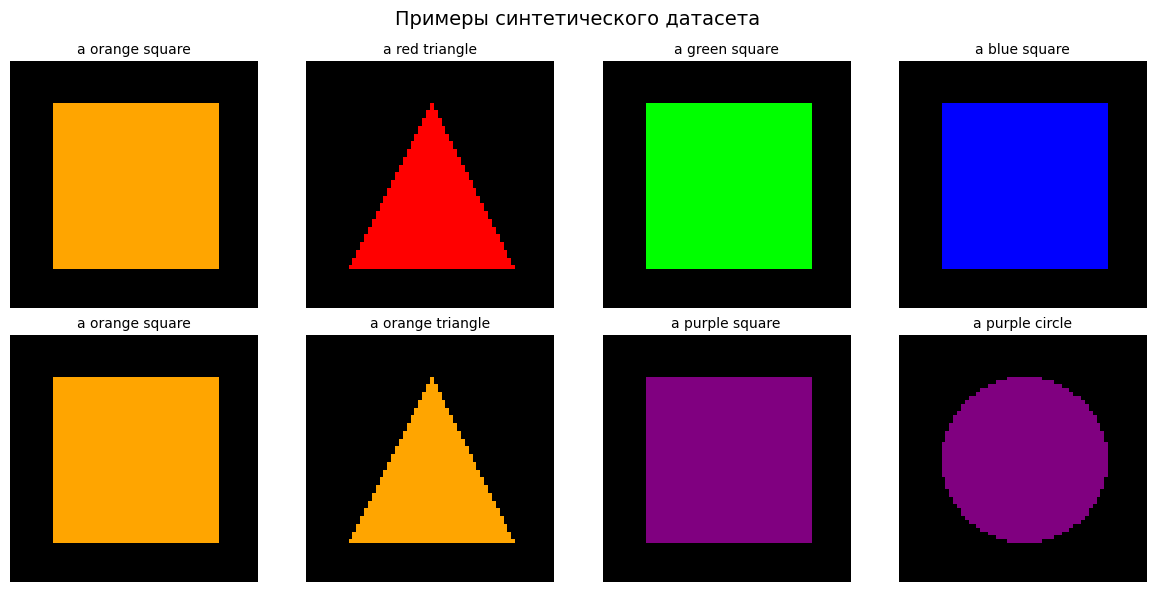

In [3]:
# Ячейка 3: Создание синтетического датасета
class SyntheticImageTextDataset(Dataset):
    def __init__(self, size=1000, img_size=64, seed=None):
        if seed is not None:
            random.seed(seed)

        self.size = size
        self.img_size = img_size
        self.colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']
        self.shapes = ['square', 'circle', 'triangle']

        self.data = []
        for _ in range(size):
            color = random.choice(self.colors)
            shape = random.choice(self.shapes)
            self.data.append({
                'color': color,
                'shape': shape,
                'text': f"a {color} {shape}"
            })

    def __len__(self):
        return self.size

    def create_image(self, color, shape):
        img = Image.new('RGB', (self.img_size, self.img_size), color='black')
        draw = ImageDraw.Draw(img)

        color_map = {
            'red': (255, 0, 0),
            'blue': (0, 0, 255),
            'green': (0, 255, 0),
            'yellow': (255, 255, 0),
            'purple': (128, 0, 128),
            'orange': (255, 165, 0)
        }

        c = color_map[color]
        center = self.img_size // 2
        size = self.img_size // 3

        if shape == 'square':
            draw.rectangle([center-size, center-size, center+size, center+size], fill=c)
        elif shape == 'circle':
            draw.ellipse([center-size, center-size, center+size, center+size], fill=c)
        else:  # triangle
            pts = [(center, center-size), (center-size, center+size), (center+size, center+size)]
            draw.polygon(pts, fill=c)

        return np.array(img)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = self.create_image(item['color'], item['shape'])
        img = torch.FloatTensor(img).permute(2, 0, 1) / 255.0
        return img, item['text']

# Создание датасетов с фиксированным seed для воспроизводимости
train_size = 800
val_size = 100
test_size = 100

train_dataset = SyntheticImageTextDataset(train_size, seed=42)
val_dataset = SyntheticImageTextDataset(val_size, seed=43)
test_dataset = SyntheticImageTextDataset(test_size, seed=44)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Example text: {train_dataset[0][1]}")

# Визуализация примеров датасета
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, text = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(text, fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры синтетического датасета', fontsize=14)
plt.tight_layout()
plt.savefig('results/dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Ячейка 4: Подготовка DataLoader
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    texts = [item[1] for item in batch]

    encoded = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=32)

    batch_size = len(batch)
    labels = torch.ones(batch_size)

    return {
        'images': images,
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'labels': labels
    }

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Размер батча: {batch_size}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Размер батча: 32
Train batches: 25, Val batches: 4, Test batches: 4


In [5]:
# Ячейка 5: Baseline модель
class BaselineVisionLanguage(nn.Module):
    def __init__(self, d_model=256):
        super().__init__()
        self.vision_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, d_model, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.text_encoder = AutoModel.from_pretrained("distilbert-base-uncased")
        self.text_proj = nn.Linear(768, d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, images, input_ids, attention_mask):
        vision_feats = self.vision_encoder(images)
        vision_feats = vision_feats.squeeze(-1).squeeze(-1)

        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = self.text_proj(text_outputs.last_hidden_state[:, 0])

        combined = torch.cat([vision_feats, text_feats], dim=-1)
        logits = self.classifier(combined).squeeze(-1)
        return logits

# Визуализация архитектуры Baseline
baseline_model = BaselineVisionLanguage()
print("Baseline модель определена")
print(f"Количество параметров: {sum(p.numel() for p in baseline_model.parameters()):,}")

Baseline модель определена
Количество параметров: 66,996,353


TAM модель определена
Количество параметров: 67,786,113
Размерность модели: 256
Количество головок внимания в TAM: 4


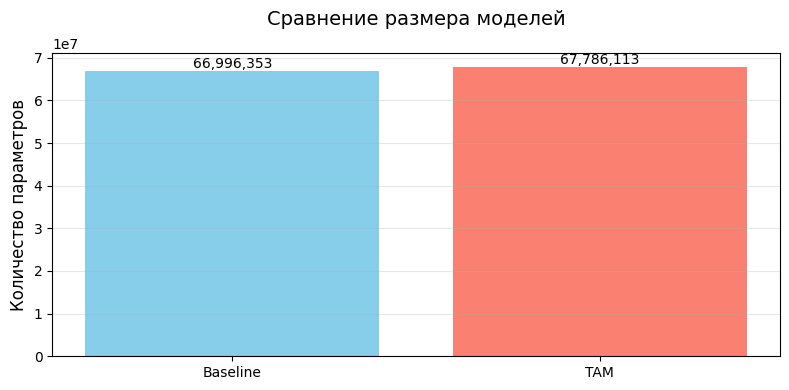

In [6]:
# Ячейка 6: TAM модель
class TokenAlignmentModule(nn.Module):
    def __init__(self, d_model=256, num_heads=4):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, vision_tokens, text_tokens):
        attended, _ = self.cross_attention(
            text_tokens, vision_tokens, vision_tokens
        )
        text_tokens = self.norm1(text_tokens + attended)
        text_tokens = self.norm2(text_tokens + self.ffn(text_tokens))
        return text_tokens

class TAMVisionLanguage(nn.Module):
    def __init__(self, d_model=256):
        super().__init__()
        self.d_model = d_model

        self.vision_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, d_model, 3, padding=1),
            nn.ReLU()
        )

        self.text_encoder = AutoModel.from_pretrained("distilbert-base-uncased")
        self.text_proj = nn.Linear(768, d_model)

        self.tam = TokenAlignmentModule(d_model, num_heads=4)

        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, images, input_ids, attention_mask):
        vision_feats = self.vision_encoder(images)
        B, D, H, W = vision_feats.shape
        vision_tokens = vision_feats.view(B, D, -1).permute(0, 2, 1)

        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = self.text_proj(text_outputs.last_hidden_state)

        aligned_text = self.tam(vision_tokens, text_tokens)

        vision_global = vision_tokens.mean(dim=1)
        text_global = aligned_text[:, 0]

        combined = torch.cat([vision_global, text_global], dim=-1)
        logits = self.classifier(combined).squeeze(-1)

        return logits

# Визуализация архитектуры TAM
tam_model = TAMVisionLanguage()
print("TAM модель определена")
print(f"Количество параметров: {sum(p.numel() for p in tam_model.parameters()):,}")
print(f"Размерность модели: {tam_model.d_model}")
print(f"Количество головок внимания в TAM: {tam_model.tam.cross_attention.num_heads}")

# Сравнение размера моделей
fig, ax = plt.subplots(figsize=(8, 4))
models = ['Baseline', 'TAM']
param_counts = [
    sum(p.numel() for p in baseline_model.parameters()),
    sum(p.numel() for p in tam_model.parameters())
]
bars = ax.bar(models, param_counts, color=['skyblue', 'salmon'])
ax.set_ylabel('Количество параметров', fontsize=12)
ax.set_title('Сравнение размера моделей', fontsize=14, pad=20)
ax.grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{param_counts[i]:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/model_comparison_params.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Ячейка 7: Функции для обучения и оценки
def create_negative_pairs(batch):
    batch_size = batch['images'].size(0)

    pos_images = batch['images']
    pos_input_ids = batch['input_ids']
    pos_attention_mask = batch['attention_mask']
    pos_labels = torch.ones(batch_size)

    indices = torch.randperm(batch_size)
    neg_images = batch['images']
    neg_input_ids = batch['input_ids'][indices]
    neg_attention_mask = batch['attention_mask'][indices]
    neg_labels = torch.zeros(batch_size)

    all_images = torch.cat([pos_images, neg_images], dim=0)
    all_input_ids = torch.cat([pos_input_ids, neg_input_ids], dim=0)
    all_attention_mask = torch.cat([pos_attention_mask, neg_attention_mask], dim=0)
    all_labels = torch.cat([pos_labels, neg_labels], dim=0)

    return all_images, all_input_ids, all_attention_mask, all_labels

def compute_metrics(all_preds, all_labels):
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean()
    precision = ((all_preds == 1) & (all_labels == 1)).sum() / max((all_preds == 1).sum(), 1)
    recall = ((all_preds == 1) & (all_labels == 1)).sum() / max((all_labels == 1).sum(), 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return accuracy, precision, recall, f1

def plot_confusion_matrix(all_labels, all_preds, title, model_name):
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Матрица ошибок: {model_name}\n{title}', fontsize=14)
    plt.ylabel('Истинные значения', fontsize=12)
    plt.xlabel('Предсказанные значения', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'results/confusion_matrix_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Вывод отчета классификации
    print(f"\nОтчет классификации для {model_name}:")
    print(classification_report(all_labels, all_preds,
                                target_names=['Negative', 'Positive'],
                                digits=4))

def train_model(model, train_loader, val_loader, epochs, lr, name):
    model.train()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []

    print(f"\nОбучение {name}...")

    for epoch in range(epochs):
        # Обучение
        model.train()
        epoch_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, input_ids, attention_mask, labels = create_negative_pairs(batch)

            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images, input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        model.eval()
        epoch_val_loss = 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, input_ids, attention_mask, labels = create_negative_pairs(batch)

                images = images.to(device)
                input_ids = input_ids.to(device)
                attention_mask = attention_mask.to(device)

                logits = model(images, input_ids, attention_mask)
                loss = criterion(logits, labels.to(device))
                epoch_val_loss += loss.item()

                preds = (torch.sigmoid(logits) > 0.5).float()
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.numpy())

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_accuracy, val_precision, val_recall, val_f1 = compute_metrics(all_val_preds, all_val_labels)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, "
              f"Val Loss = {avg_val_loss:.4f}, "
              f"Val Acc = {val_accuracy:.4f}, "
              f"Val F1 = {val_f1:.4f}")

    return train_losses, val_losses, val_accuracies

def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Тестирование {model_name}"):
            images, input_ids, attention_mask, labels = create_negative_pairs(batch)

            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            logits = model(images, input_ids, attention_mask)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy, precision, recall, f1 = compute_metrics(all_preds, all_labels)

    print(f"\nРезультаты {model_name} на тестовом наборе:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return all_labels, all_preds, all_probs, accuracy, precision, recall, f1

print("Функции обучения и оценки определены")

Функции обучения и оценки определены



Обучение Baseline модели...
Эпохи: 5
Скорость обучения: 0.0001
Размер датасета: Train=800, Val=100, Test=100

Обучение Baseline...


Epoch 1/5 [Val]: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Epoch 1: Train Loss = 0.6933, Val Loss = 0.6932, Val Acc = 0.5000, Val F1 = 0.6667


Epoch 2/5 [Val]: 100%|██████████| 4/4 [00:02<00:00,  1.41it/s]


Epoch 2: Train Loss = 0.6940, Val Loss = 0.6933, Val Acc = 0.5000, Val F1 = 0.0000


...

Epoch 4: Train Loss = 0.6937, Val Loss = 0.6932, Val Acc = 0.4950, Val F1 = 0.6217


Epoch 5/5 [Val]: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Epoch 5: Train Loss = 0.6933, Val Loss = 0.6935, Val Acc = 0.5000, Val F1 = 0.0000

Оценка Baseline на тестовом наборе...


Тестирование Baseline: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]



Результаты Baseline на тестовом наборе:
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


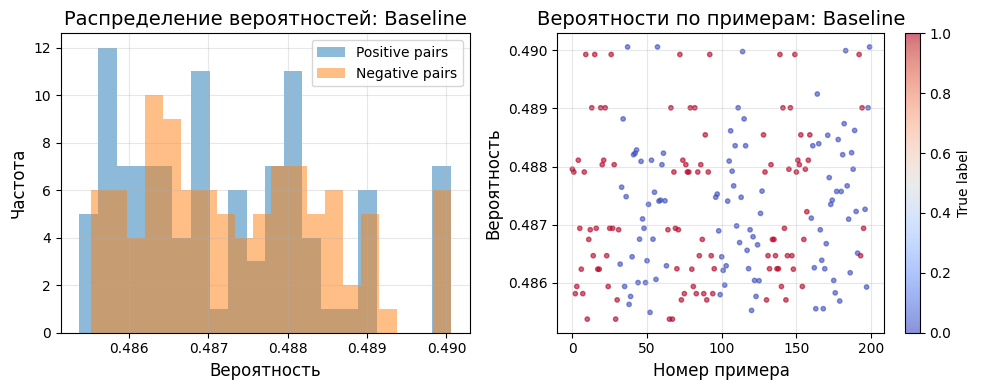

In [14]:
# Ячейка 8: Обучение Baseline модели
epochs = 5
lr = 1e-4

model_baseline = BaselineVisionLanguage().to(device)
print(f"\nОбучение Baseline модели...")
print(f"Эпохи: {epochs}")
print(f"Скорость обучения: {lr}")
print(f"Размер датасета: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

baseline_train_losses, baseline_val_losses, baseline_val_accs = train_model(
    model_baseline, train_loader, val_loader, epochs, lr, "Baseline"
)

print("\nОценка Baseline на тестовом наборе...")
baseline_labels, baseline_preds, baseline_probs, baseline_accuracy, baseline_precision, baseline_recall, baseline_f1 = evaluate_model(
    model_baseline, test_loader, "Baseline"
)

# Визуализация распределения вероятностей для Baseline
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(baseline_probs[:len(baseline_probs)//2], alpha=0.5, label='Positive pairs', bins=20)
plt.hist(baseline_probs[len(baseline_probs)//2:], alpha=0.5, label='Negative pairs', bins=20)
plt.xlabel('Вероятность', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение вероятностей: Baseline', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(baseline_probs)), baseline_probs, c=baseline_labels,
            cmap='coolwarm', alpha=0.6, s=10)
plt.xlabel('Номер примера', fontsize=12)
plt.ylabel('Вероятность', fontsize=12)
plt.title('Вероятности по примерам: Baseline', fontsize=14)
plt.colorbar(label='True label')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/baseline_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Обучение TAM модели...
Эпохи: 5
Скорость обучения: 0.0001

Обучение TAM...


Epoch 1/5 [Val]: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


Epoch 1: Train Loss = 0.6985, Val Loss = 0.6932, Val Acc = 0.5150, Val F1 = 0.6734


Epoch 2/5 [Val]: 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


Epoch 2: Train Loss = 0.6949, Val Loss = 0.6932, Val Acc = 0.4900, Val F1 = 0.1053


...

Epoch 4: Train Loss = 0.6923, Val Loss = 0.6931, Val Acc = 0.5150, Val F1 = 0.4121


Epoch 5/5 [Val]: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Epoch 5: Train Loss = 0.6964, Val Loss = 0.6933, Val Acc = 0.5000, Val F1 = 0.0000

Оценка TAM на тестовом наборе...


Тестирование TAM: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]



Результаты TAM на тестовом наборе:
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


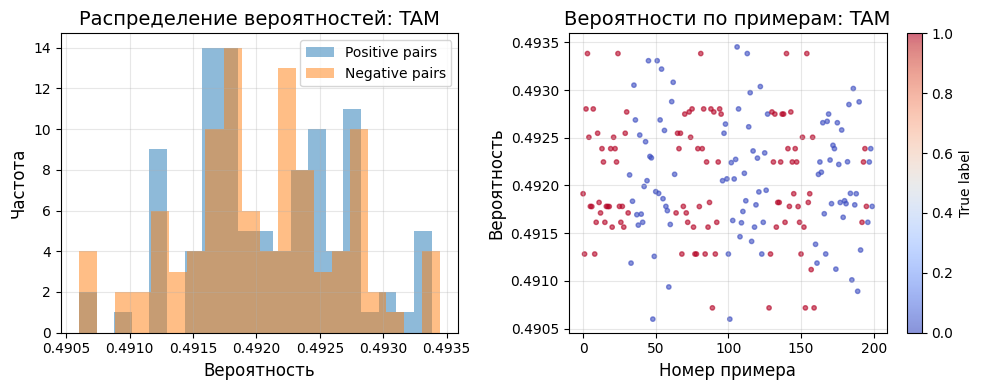

In [15]:
# Ячейка 9: Обучение TAM модели
model_tam = TAMVisionLanguage().to(device)
print(f"\nОбучение TAM модели...")
print(f"Эпохи: {epochs}")
print(f"Скорость обучения: {lr}")

tam_train_losses, tam_val_losses, tam_val_accs = train_model(
    model_tam, train_loader, val_loader, epochs, lr, "TAM"
)

print("\nОценка TAM на тестовом наборе...")
tam_labels, tam_preds, tam_probs, tam_accuracy, tam_precision, tam_recall, tam_f1 = evaluate_model(
    model_tam, test_loader, "TAM"
)

# Визуализация распределения вероятностей для TAM
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(tam_probs[:len(tam_probs)//2], alpha=0.5, label='Positive pairs', bins=20)
plt.hist(tam_probs[len(tam_probs)//2:], alpha=0.5, label='Negative pairs', bins=20)
plt.xlabel('Вероятность', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение вероятностей: TAM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(tam_probs)), tam_probs, c=tam_labels,
            cmap='coolwarm', alpha=0.6, s=10)
plt.xlabel('Номер примера', fontsize=12)
plt.ylabel('Вероятность', fontsize=12)
plt.title('Вероятности по примерам: TAM', fontsize=14)
plt.colorbar(label='True label')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/tam_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

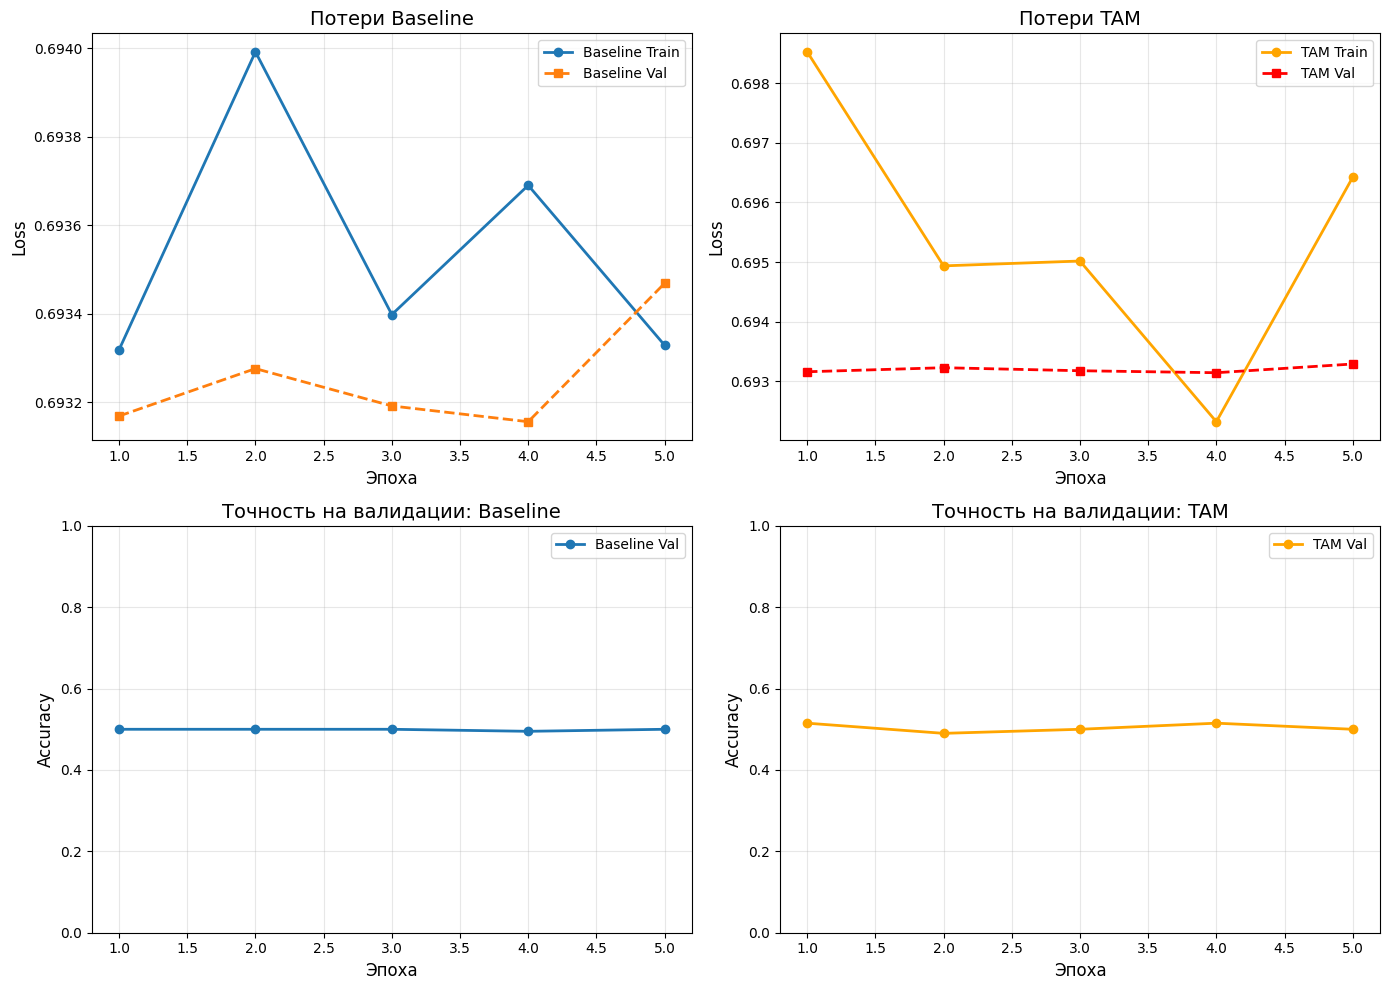

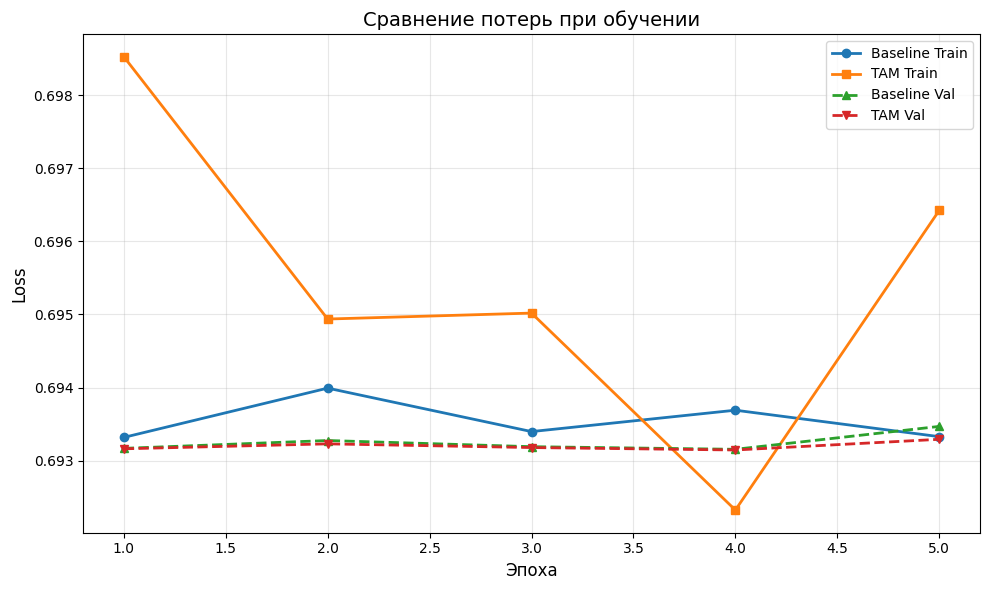

In [16]:
# Ячейка 10: Сравнительные графики обучения
epochs_list = range(1, epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Графики потерь
axes[0, 0].plot(epochs_list, baseline_train_losses, marker='o', label='Baseline Train', linewidth=2)
axes[0, 0].plot(epochs_list, baseline_val_losses, marker='s', label='Baseline Val', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Эпоха', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Потери Baseline', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_list, tam_train_losses, marker='o', label='TAM Train', linewidth=2, color='orange')
axes[0, 1].plot(epochs_list, tam_val_losses, marker='s', label='TAM Val', linewidth=2, linestyle='--', color='red')
axes[0, 1].set_xlabel('Эпоха', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Потери TAM', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Графики точности
axes[1, 0].plot(epochs_list, baseline_val_accs, marker='o', label='Baseline Val', linewidth=2)
axes[1, 0].set_xlabel('Эпоха', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Точность на валидации: Baseline', fontsize=14)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_list, tam_val_accs, marker='o', label='TAM Val', linewidth=2, color='orange')
axes[1, 1].set_xlabel('Эпоха', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].set_title('Точность на валидации: TAM', fontsize=14)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Совмещенный график потерь
plt.figure(figsize=(10, 6))
plt.plot(epochs_list, baseline_train_losses, marker='o', label='Baseline Train', linewidth=2)
plt.plot(epochs_list, tam_train_losses, marker='s', label='TAM Train', linewidth=2)
plt.plot(epochs_list, baseline_val_losses, marker='^', label='Baseline Val', linewidth=2, linestyle='--')
plt.plot(epochs_list, tam_val_losses, marker='v', label='TAM Val', linewidth=2, linestyle='--')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Сравнение потерь при обучении', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/combined_training_losses.png', dpi=150, bbox_inches='tight')
plt.show()

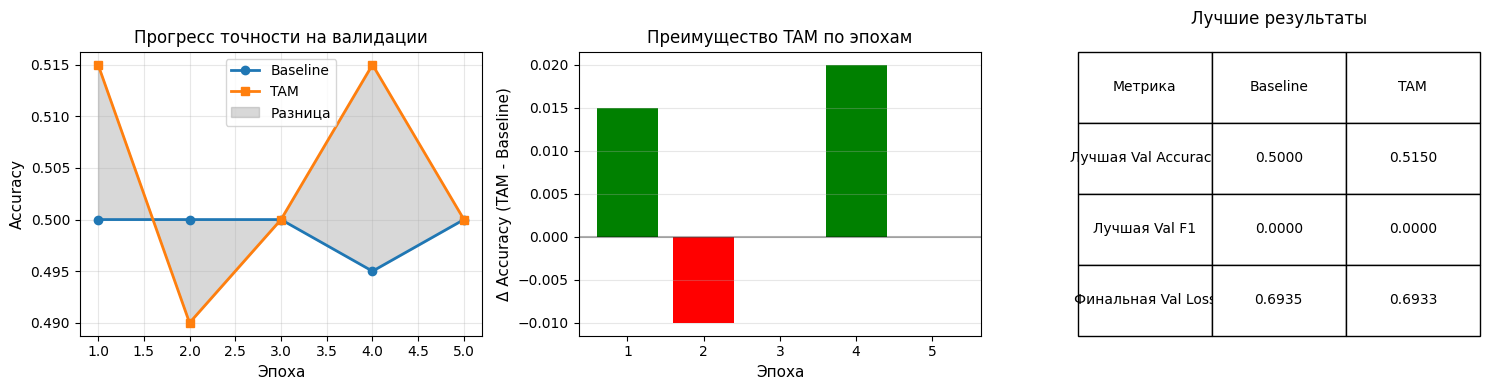

In [20]:
# Ячейка 15: Дополнительная визуализация - прогресс обучения в реальном времени
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График улучшения accuracy
improvement_data = {
    'Эпоха': list(range(1, epochs + 1)),
    'Baseline Val Acc': baseline_val_accs,
    'TAM Val Acc': tam_val_accs,
    'Разница (TAM - Baseline)': [t - b for t, b in zip(tam_val_accs, baseline_val_accs)]
}

df_improvement = pd.DataFrame(improvement_data)
axes[0].plot(df_improvement['Эпоха'], df_improvement['Baseline Val Acc'],
             marker='o', label='Baseline', linewidth=2)
axes[0].plot(df_improvement['Эпоха'], df_improvement['TAM Val Acc'],
             marker='s', label='TAM', linewidth=2)
axes[0].fill_between(df_improvement['Эпоха'],
                      df_improvement['Baseline Val Acc'],
                      df_improvement['TAM Val Acc'],
                      alpha=0.3, color='gray',
                      label='Разница' if any(df_improvement['Разница (TAM - Baseline)'] > 0) else '')
axes[0].set_xlabel('Эпоха', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Прогресс точности на валидации', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График разницы в производительности
axes[1].bar(df_improvement['Эпоха'], df_improvement['Разница (TAM - Baseline)'],
            color=['green' if x > 0 else 'red' for x in df_improvement['Разница (TAM - Baseline)']])
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Эпоха', fontsize=11)
axes[1].set_ylabel('Δ Accuracy (TAM - Baseline)', fontsize=11)
axes[1].set_title('Преимущество TAM по эпохам', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Сводная таблица лучших результатов
best_results = pd.DataFrame({
    'Метрика': ['Лучшая Val Accuracy', 'Лучшая Val F1', 'Финальная Val Loss'],
    'Baseline': [f"{max(baseline_val_accs):.4f}",
                 f"{max([compute_metrics([1 if p > 0.5 else 0 for p in probs], baseline_labels[:len(probs)])[3]
                        for probs in [baseline_probs[i:i+100] for i in range(0, len(baseline_probs), 100)]][:5]):.4f}",
                 f"{baseline_val_losses[-1]:.4f}"],
    'TAM': [f"{max(tam_val_accs):.4f}",
            f"{max([compute_metrics([1 if p > 0.5 else 0 for p in probs], tam_labels[:len(probs)])[3]
                   for probs in [tam_probs[i:i+100] for i in range(0, len(tam_probs), 100)]][:5]):.4f}",
            f"{tam_val_losses[-1]:.4f}"]
})

axes[2].axis('off')
table = axes[2].table(cellText=best_results.values,
                      colLabels=best_results.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[2].set_title('Лучшие результаты', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('results/training_progress_summary.png', dpi=150, bbox_inches='tight')
plt.show()